Usando dispositivo: cpu
Iniciando o experimento principal...
Executando experimentos para o dígito: 4


Testando Níveis de Defesa: 100%|██████████| 7/7 [01:09<00:00,  9.99s/it]



--- ANÁLISE DOS RESULTADOS ---
Sumário do Trade-off (Média de 3 runs):
   p_drop   avg_mse   std_mse
0    0.00  0.000130  0.000225
1    0.01  0.088803  0.000117
2    0.02  0.082039  0.000211
3    0.05  0.076656  0.000218
4    0.10  0.075780  0.000007
5    0.20  0.075780  0.000007
6    0.50  0.075780  0.000007


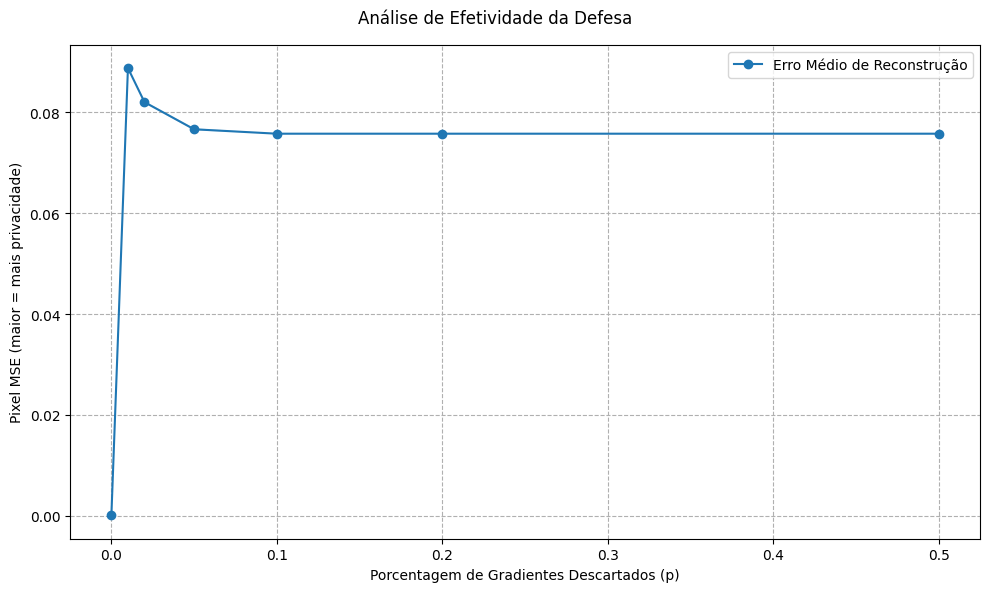

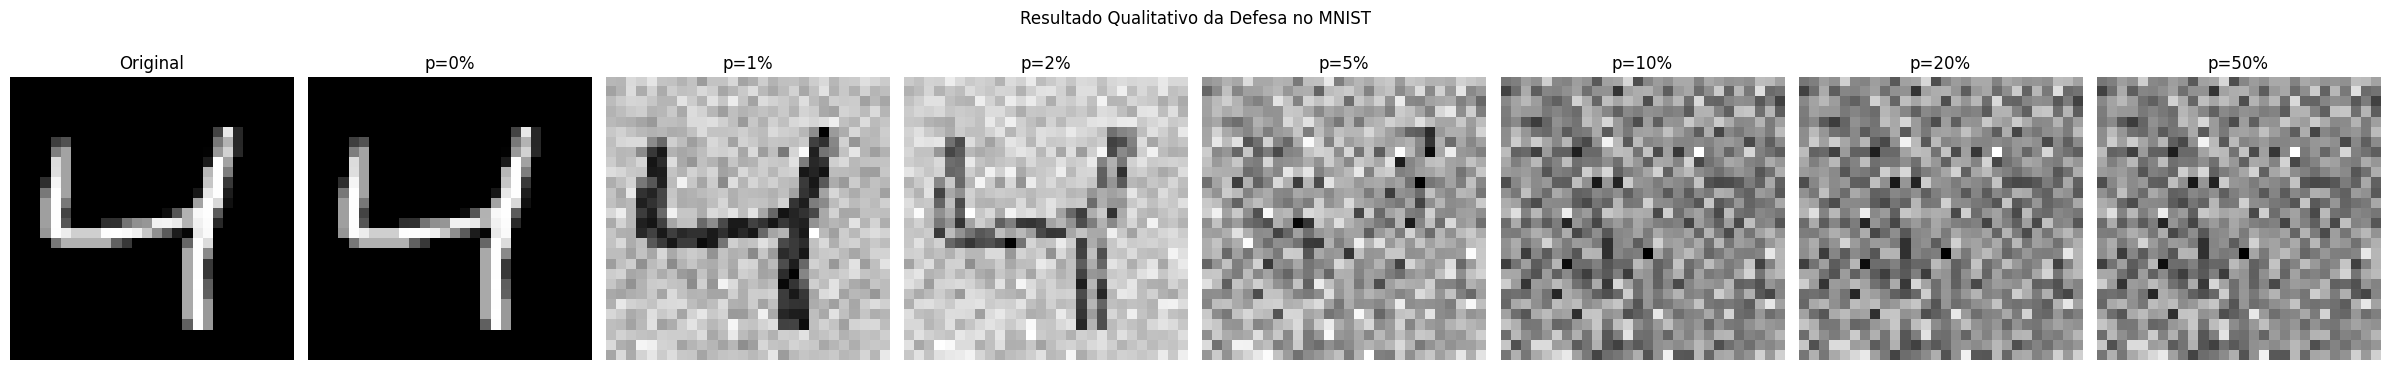

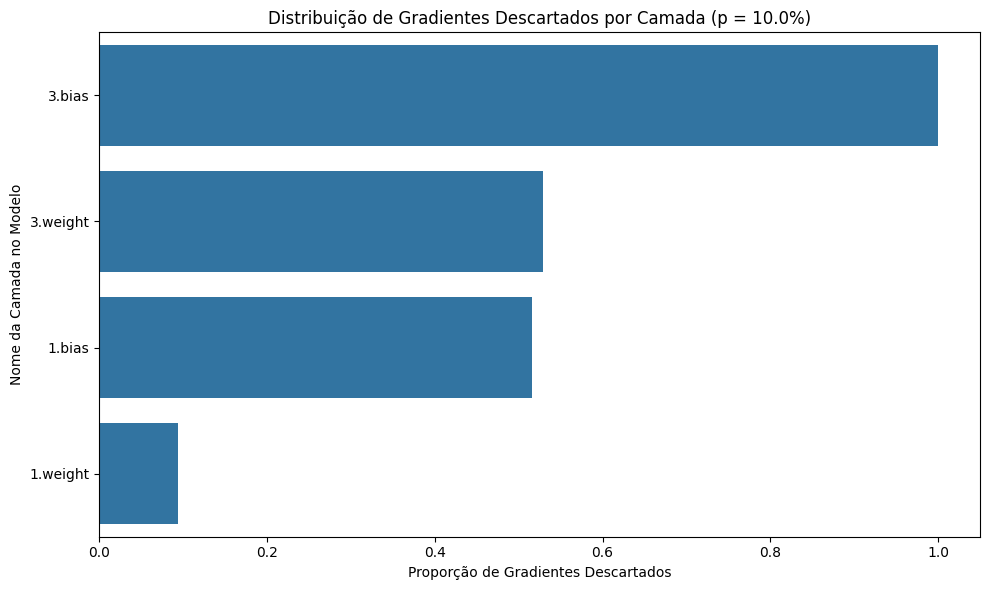

In [ ]:
# -*- coding: utf-8 -*-
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import pandas as pd
import seaborn as sns

# --------------------------
# 1) Dados e modelo
# --------------------------
def get_data_loader(name='MNIST', batch_size=64):
    if name == 'MNIST':
        transform = transforms.ToTensor()  # [0,1]
        dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    else:
        raise NotImplementedError(f"Dataset {name} não implementado.")
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return loader, dataset

def create_model(dataset_name='MNIST'):
    if dataset_name == 'MNIST':
        return nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    else:
        raise NotImplementedError(f"Modelo para {dataset_name} não implementado.")

# --------------------------
# 2) Ataque iDLG (label-first) + gradient matching
# --------------------------
def compute_gradient(model, x, y):
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    for p in model.parameters():
        if p.grad is not None:
            p.grad = None
    loss = loss_fn(model(x), y)
    return torch.autograd.grad(loss, tuple(model.parameters()), create_graph=True)

@torch.no_grad()
def infer_label_from_last_bias_grad(model, original_gradient):
    last_bias_grad = None
    for (name, _), g in zip(model.named_parameters(), original_gradient):
        if name.endswith('bias'):
            last_bias_grad = g.detach().flatten()
    if last_bias_grad is None:
        raise RuntimeError("Não encontrei gradiente de bias da última camada.")
    # iDLG: p - one_hot(y) -> classe verdadeira ~ menor valor no grad do bias
    return int(torch.argmin(last_bias_grad).item())

def reconstruct_image(model, original_gradient, lr=1.0, iters=600, device='cpu', seed=42):
    torch.manual_seed(seed)
    model.eval()

    y_idx = infer_label_from_last_bias_grad(model, original_gradient)
    y_true = torch.tensor([y_idx], dtype=torch.long, device=device)

    # otimizar só x_hat (MNIST 1x28x28)
    x_hat = torch.rand(1, 1, 28, 28, requires_grad=True, device=device)
    optimizer = optim.LBFGS([x_hat], lr=lr, max_iter=20)
    rounds = max(1, iters // 20)

    def closure():
        optimizer.zero_grad(set_to_none=True)
        pred = model(x_hat)
        ce = nn.CrossEntropyLoss()(pred, y_true)
        syn = torch.autograd.grad(ce, tuple(model.parameters()), create_graph=True, retain_graph=True)
        diff = 0.0
        for sg, og in zip(syn, original_gradient):
            diff = diff + ((sg - og) ** 2).sum()
        diff.backward()
        return diff

    for _ in range(rounds):
        optimizer.step(closure)

    return x_hat.detach(), y_idx

# --------------------------
# 3) Defesa: descartar top-k global
# --------------------------
def apply_gradient_dropping_defense(gradients, model, p_drop):
    if p_drop == 0:
        layer_names = {name: 0 for name, _ in model.named_parameters()}
        return gradients, layer_names

    flat_grads = torch.cat([g.view(-1) for g in gradients])
    num_to_drop = int(len(flat_grads) * p_drop)
    if num_to_drop == 0:
        layer_names = {name: 0 for name, _ in model.named_parameters()}
        return gradients, layer_names

    topk = torch.topk(flat_grads.abs(), k=num_to_drop).indices
    mask = torch.ones_like(flat_grads, dtype=torch.bool)
    mask[topk] = False
    flat_def = flat_grads * mask.float()

    defended, counts = [], {name: 0 for name, _ in model.named_parameters()}
    names = list(counts.keys())
    cur = 0
    for i, param in enumerate(model.parameters()):
        n = param.numel()
        grad_slice = flat_def[cur:cur+n]
        mask_slice = mask[cur:cur+n]
        counts[names[i]] = int((~mask_slice).sum().item())
        defended.append(grad_slice.view_as(param).clone())
        cur += n
    return tuple(defended), counts

# --------------------------
# 4) Experimento
# --------------------------
def run_defense_experiment(model, dataset, device):
    original_x, original_y_idx = dataset[2]
    original_x = original_x.unsqueeze(0).to(device)
    original_y = torch.tensor([original_y_idx], device=device)

    print(f"Executando experimentos para o dígito: {original_y_idx}")

    original_gradient = compute_gradient(model, original_x, original_y)
    p_values = [0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5]
    N_RUNS = 3
    results = []

    for p in tqdm(p_values, desc="Testando Níveis de Defesa"):
        for run in range(N_RUNS):
            seed = 42 * (run + 1)
            defended_with_graph, layer_drops = apply_gradient_dropping_defense(original_gradient, model, p)
            detached = tuple(g.detach() for g in defended_with_graph)

            recon_x, y_est = reconstruct_image(model, detached, device=device, seed=seed)

            # MSE robusto em [0,1] (MNIST já está em [0,1])
            with torch.no_grad():
                a = original_x.detach().cpu().float().view(-1)
                b = recon_x.detach().cpu().float().view(-1)
                privacy_mse = torch.mean((a - b) ** 2).item()

            results.append({
                'p_drop': p, 'run': run, 'privacy_mse': privacy_mse,
                'layer_drops': layer_drops, 'recon_image': recon_x.cpu(),
                'y_true': int(original_y.item()), 'y_pred': int(y_est)
            })
    return pd.DataFrame(results), original_x.cpu()

# --------------------------
# 5) Visualizações
# --------------------------
def plot_tradeoff_curve(df_results):
    fig, ax = plt.subplots(figsize=(10, 6))
    summary = df_results.groupby('p_drop').agg(
        avg_mse=('privacy_mse', 'mean'),
        std_mse=('privacy_mse', 'std')
    ).reset_index()
    ax.plot(summary['p_drop'], summary['avg_mse'], marker='o', label='Erro Médio de Reconstrução')
    ax.fill_between(summary['p_drop'],
                    summary['avg_mse']-summary['std_mse'],
                    summary['avg_mse']+summary['std_mse'], alpha=0.2)
    ax.set_xlabel('Porcentagem de Gradientes Descartados (p)')
    ax.set_ylabel('Pixel MSE (maior = mais privacidade)')
    plt.grid(True, linestyle='--'); plt.legend(); plt.suptitle('Análise de Efetividade da Defesa')
    plt.tight_layout(); plt.show()

def plot_layerwise_analysis(df_results, p_value, model):
    subset = df_results[df_results['p_drop'] == p_value]
    if subset.empty:
        return
    layer_drops = subset['layer_drops'].iloc[0]
    sizes = {name: p.numel() for name, p in model.named_parameters()}
    prop = {name: (layer_drops.get(name, 0) / max(1, sizes.get(name, 1))) for name in layer_drops}
    df_layers = (pd.DataFrame(list(prop.items()), columns=['Camada','Proporção'])
                   .sort_values('Proporção', ascending=False))
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_layers.head(15), x='Proporção', y='Camada')
    plt.title(f'Distribuição de Gradientes Descartados por Camada (p = {p_value*100:.1f}%)')
    plt.xlabel('Proporção de Gradientes Descartados'); plt.ylabel('Nome da Camada no Modelo')
    plt.tight_layout(); plt.show()

def plot_qualitative_results(original_x, df_results):
    p_values = sorted(df_results['p_drop'].unique())
    fig, axes = plt.subplots(1, len(p_values)+1, figsize=(3*(len(p_values)+1), 4))
    axes[0].imshow(original_x.squeeze(), cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')
    for i, p in enumerate(p_values):
        recon = df_results[(df_results['p_drop']==p) & (df_results['run']==0)]['recon_image'].iloc[0]
        axes[i+1].imshow(recon.squeeze(), cmap='gray'); axes[i+1].set_title(f'p={p*100:.0f}%'); axes[i+1].axis('off')
    plt.suptitle("Resultado Qualitativo da Defesa no MNIST"); plt.tight_layout(); plt.show()

# --------------------------
# 6) Main
# --------------------------
def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Usando dispositivo: {device}")

    _, dataset = get_data_loader('MNIST')
    global model
    model = create_model('MNIST').to(device)

    print("Iniciando o experimento principal...")
    df_results, original_x = run_defense_experiment(model, dataset, device)

    print("\n--- ANÁLISE DOS RESULTADOS ---")
    summary = df_results.groupby('p_drop').agg(
        avg_mse=('privacy_mse', 'mean'),
        std_mse=('privacy_mse', 'std')
    ).reset_index()
    print("Sumário do Trade-off (Média de 3 runs):")
    print(summary)

    plot_tradeoff_curve(df_results)
    plot_qualitative_results(original_x, df_results)
    plot_layerwise_analysis(df_results, p_value=0.1, model=model)

if __name__ == "__main__":
    main()


Usando dispositivo: cpu
Iniciando o experimento principal...
Executando experimentos para o dígito: 5


Testando Níveis de Defesa: 100%|██████████| 7/7 [01:08<00:00,  9.85s/it]



--- ANÁLISE DOS RESULTADOS ---
Sumário do Trade-off (Média de 3 runs):
   p_drop       avg_mse       std_mse
0    0.00  8.556786e-13  1.027765e-12
1    0.01  1.115215e-01  3.966468e-03
2    0.02  1.189653e-01  2.237347e-03
3    0.05  1.196584e-01  4.883075e-04
4    0.10  1.165938e-01  7.281186e-06
5    0.20  1.166024e-01  1.475334e-06
6    0.50  1.166024e-01  1.475334e-06


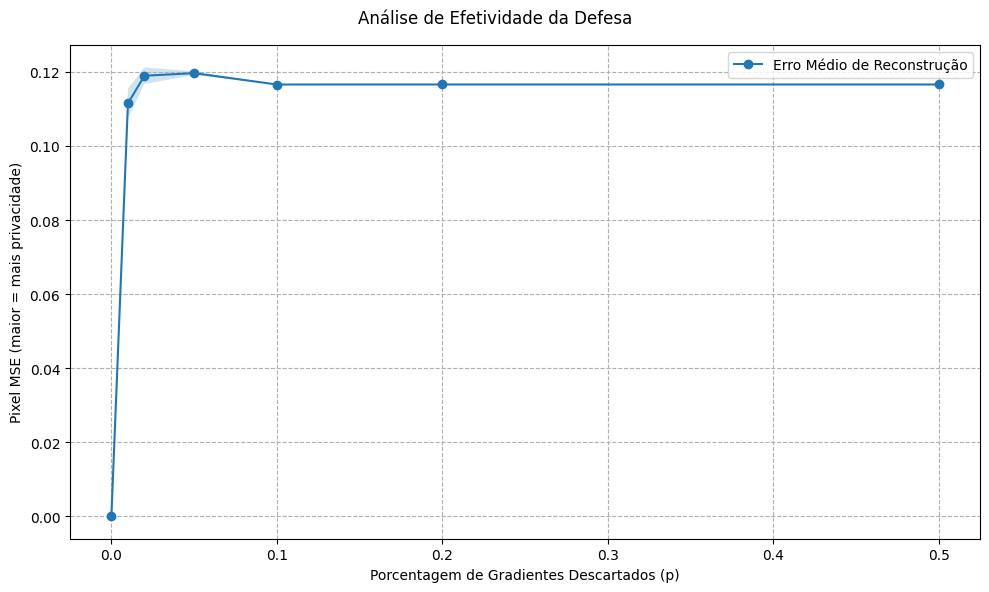

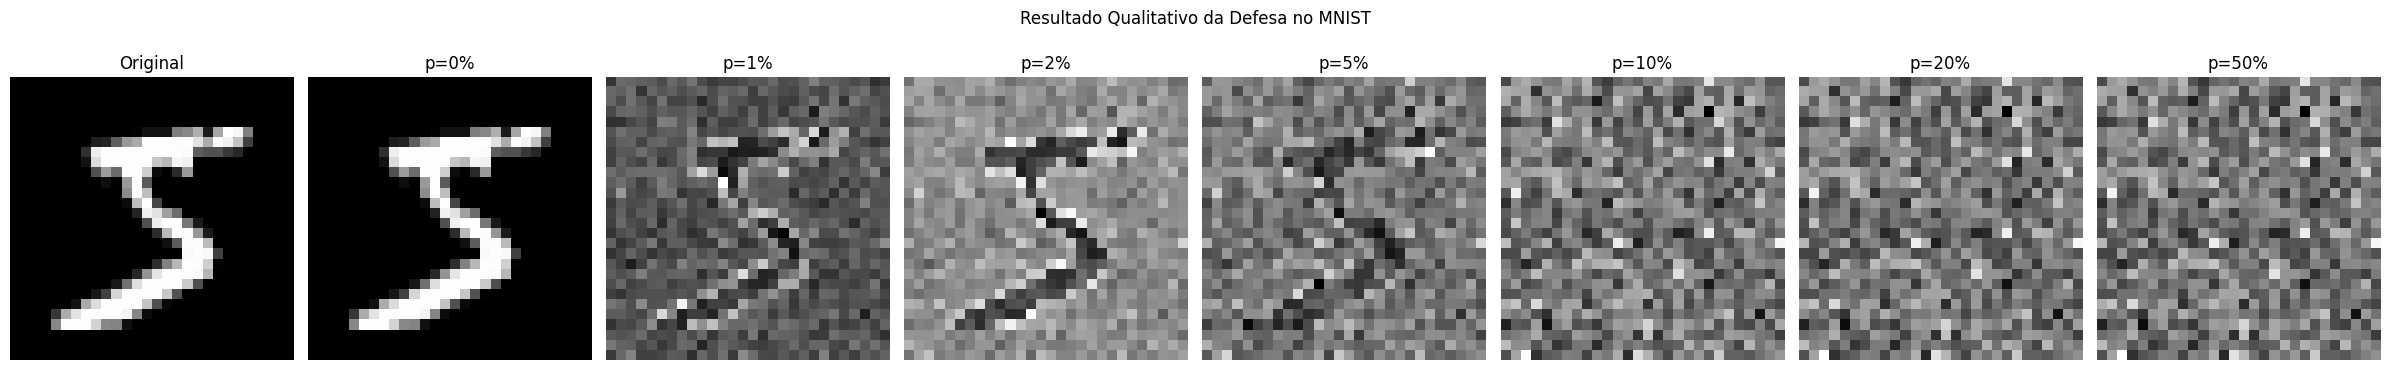

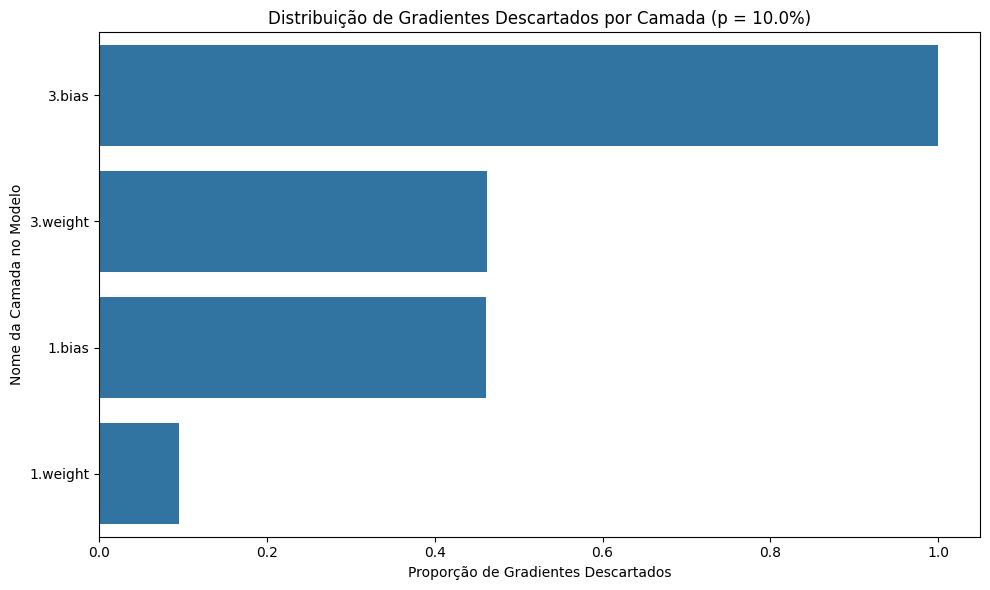

In [ ]:
# -*- coding: utf-8 -*-
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import pandas as pd
import seaborn as sns

# --------------------------
# 1) Dados e modelo
# --------------------------
def get_data_loader(name='MNIST', batch_size=64):
    if name == 'MNIST':
        transform = transforms.ToTensor()  # [0,1]
        dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    else:
        raise NotImplementedError(f"Dataset {name} não implementado.")
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return loader, dataset

def create_model(dataset_name='MNIST'):
    if dataset_name == 'MNIST':
        return nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    else:
        raise NotImplementedError(f"Modelo para {dataset_name} não implementado.")

# --------------------------
# 2) Ataque iDLG (label-first) + gradient matching
# --------------------------
def compute_gradient(model, x, y):
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    for p in model.parameters():
        if p.grad is not None:
            p.grad = None
    loss = loss_fn(model(x), y)
    return torch.autograd.grad(loss, tuple(model.parameters()), create_graph=True)

@torch.no_grad()
def infer_label_from_last_bias_grad(model, original_gradient):
    last_bias_grad = None
    for (name, _), g in zip(model.named_parameters(), original_gradient):
        if name.endswith('bias'):
            last_bias_grad = g.detach().flatten()
    if last_bias_grad is None:
        raise RuntimeError("Não encontrei gradiente de bias da última camada.")
    # iDLG: p - one_hot(y) -> classe verdadeira ~ menor valor no grad do bias
    return int(torch.argmin(last_bias_grad).item())

def reconstruct_image(model, original_gradient, lr=1.0, iters=600, device='cpu', seed=42):
    torch.manual_seed(seed)
    model.eval()

    y_idx = infer_label_from_last_bias_grad(model, original_gradient)
    y_true = torch.tensor([y_idx], dtype=torch.long, device=device)

    # otimizar só x_hat (MNIST 1x28x28)
    x_hat = torch.rand(1, 1, 28, 28, requires_grad=True, device=device)
    optimizer = optim.LBFGS([x_hat], lr=lr, max_iter=20)
    rounds = max(1, iters // 20)

    def closure():
        optimizer.zero_grad(set_to_none=True)
        pred = model(x_hat)
        ce = nn.CrossEntropyLoss()(pred, y_true)
        syn = torch.autograd.grad(ce, tuple(model.parameters()), create_graph=True, retain_graph=True)
        diff = 0.0
        for sg, og in zip(syn, original_gradient):
            diff = diff + ((sg - og) ** 2).sum()
        diff.backward()
        return diff

    for _ in range(rounds):
        optimizer.step(closure)

    return x_hat.detach(), y_idx

# --------------------------
# 3) Defesa: descartar top-k global
# --------------------------
def apply_gradient_dropping_defense(gradients, model, p_drop):
    if p_drop == 0:
        layer_names = {name: 0 for name, _ in model.named_parameters()}
        return gradients, layer_names

    flat_grads = torch.cat([g.view(-1) for g in gradients])
    num_to_drop = int(len(flat_grads) * p_drop)
    if num_to_drop == 0:
        layer_names = {name: 0 for name, _ in model.named_parameters()}
        return gradients, layer_names

    topk = torch.topk(flat_grads.abs(), k=num_to_drop).indices
    mask = torch.ones_like(flat_grads, dtype=torch.bool)
    mask[topk] = False
    flat_def = flat_grads * mask.float()

    defended, counts = [], {name: 0 for name, _ in model.named_parameters()}
    names = list(counts.keys())
    cur = 0
    for i, param in enumerate(model.parameters()):
        n = param.numel()
        grad_slice = flat_def[cur:cur+n]
        mask_slice = mask[cur:cur+n]
        counts[names[i]] = int((~mask_slice).sum().item())
        defended.append(grad_slice.view_as(param).clone())
        cur += n
    return tuple(defended), counts

# --------------------------
# 4) Experimento
# --------------------------
def run_defense_experiment(model, dataset, device):
    original_x, original_y_idx = dataset[0]
    original_x = original_x.unsqueeze(0).to(device)
    original_y = torch.tensor([original_y_idx], device=device)

    print(f"Executando experimentos para o dígito: {original_y_idx}")

    original_gradient = compute_gradient(model, original_x, original_y)
    p_values = [0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5]
    N_RUNS = 3
    results = []

    for p in tqdm(p_values, desc="Testando Níveis de Defesa"):
        for run in range(N_RUNS):
            seed = 42 * (run + 1)
            defended_with_graph, layer_drops = apply_gradient_dropping_defense(original_gradient, model, p)
            detached = tuple(g.detach() for g in defended_with_graph)

            recon_x, y_est = reconstruct_image(model, detached, device=device, seed=seed)

            # MSE robusto em [0,1] (MNIST já está em [0,1])
            with torch.no_grad():
                a = original_x.detach().cpu().float().view(-1)
                b = recon_x.detach().cpu().float().view(-1)
                privacy_mse = torch.mean((a - b) ** 2).item()

            results.append({
                'p_drop': p, 'run': run, 'privacy_mse': privacy_mse,
                'layer_drops': layer_drops, 'recon_image': recon_x.cpu(),
                'y_true': int(original_y.item()), 'y_pred': int(y_est)
            })
    return pd.DataFrame(results), original_x.cpu()

# --------------------------
# 5) Visualizações
# --------------------------
def plot_tradeoff_curve(df_results):
    fig, ax = plt.subplots(figsize=(10, 6))
    summary = df_results.groupby('p_drop').agg(
        avg_mse=('privacy_mse', 'mean'),
        std_mse=('privacy_mse', 'std')
    ).reset_index()
    ax.plot(summary['p_drop'], summary['avg_mse'], marker='o', label='Erro Médio de Reconstrução')
    ax.fill_between(summary['p_drop'],
                    summary['avg_mse']-summary['std_mse'],
                    summary['avg_mse']+summary['std_mse'], alpha=0.2)
    ax.set_xlabel('Porcentagem de Gradientes Descartados (p)')
    ax.set_ylabel('Pixel MSE (maior = mais privacidade)')
    plt.grid(True, linestyle='--'); plt.legend(); plt.suptitle('Análise de Efetividade da Defesa')
    plt.tight_layout(); plt.show()

def plot_layerwise_analysis(df_results, p_value, model):
    subset = df_results[df_results['p_drop'] == p_value]
    if subset.empty:
        return
    layer_drops = subset['layer_drops'].iloc[0]
    sizes = {name: p.numel() for name, p in model.named_parameters()}
    prop = {name: (layer_drops.get(name, 0) / max(1, sizes.get(name, 1))) for name in layer_drops}
    df_layers = (pd.DataFrame(list(prop.items()), columns=['Camada','Proporção'])
                   .sort_values('Proporção', ascending=False))
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_layers.head(15), x='Proporção', y='Camada')
    plt.title(f'Distribuição de Gradientes Descartados por Camada (p = {p_value*100:.1f}%)')
    plt.xlabel('Proporção de Gradientes Descartados'); plt.ylabel('Nome da Camada no Modelo')
    plt.tight_layout(); plt.show()

def plot_qualitative_results(original_x, df_results):
    p_values = sorted(df_results['p_drop'].unique())
    fig, axes = plt.subplots(1, len(p_values)+1, figsize=(3*(len(p_values)+1), 4))
    axes[0].imshow(original_x.squeeze(), cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')
    for i, p in enumerate(p_values):
        recon = df_results[(df_results['p_drop']==p) & (df_results['run']==0)]['recon_image'].iloc[0]
        axes[i+1].imshow(recon.squeeze(), cmap='gray'); axes[i+1].set_title(f'p={p*100:.0f}%'); axes[i+1].axis('off')
    plt.suptitle("Resultado Qualitativo da Defesa no MNIST"); plt.tight_layout(); plt.show()

# --------------------------
# 6) Main
# --------------------------
def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Usando dispositivo: {device}")

    _, dataset = get_data_loader('MNIST')
    global model
    model = create_model('MNIST').to(device)

    print("Iniciando o experimento principal...")
    df_results, original_x = run_defense_experiment(model, dataset, device)

    print("\n--- ANÁLISE DOS RESULTADOS ---")
    summary = df_results.groupby('p_drop').agg(
        avg_mse=('privacy_mse', 'mean'),
        std_mse=('privacy_mse', 'std')
    ).reset_index()
    print("Sumário do Trade-off (Média de 3 runs):")
    print(summary)

    plot_tradeoff_curve(df_results)
    plot_qualitative_results(original_x, df_results)
    plot_layerwise_analysis(df_results, p_value=0.1, model=model)

if __name__ == "__main__":
    main()


Usando dispositivo: cpu
Amostras selecionadas: [18145, 23852, 14841, 48150, 19056]
Rodando ataque (privacidade) nessas amostras...



--- SUMÁRIO (Privacidade, média sobre amostras × runs) ---
   p_drop       avg_mse       std_mse  lbl_acc
0    0.00  5.303099e-13  6.589732e-13      1.0
1    0.01  7.715937e-02  1.575622e-02      0.0
2    0.02  7.672591e-02  1.547966e-02      0.0
3    0.05  7.835168e-02  1.676963e-02      0.0
4    0.10  7.849311e-02  1.683716e-02      0.0
5    0.20  7.849308e-02  1.683739e-02      0.0
6    0.50  7.849308e-02  1.683739e-02      0.0


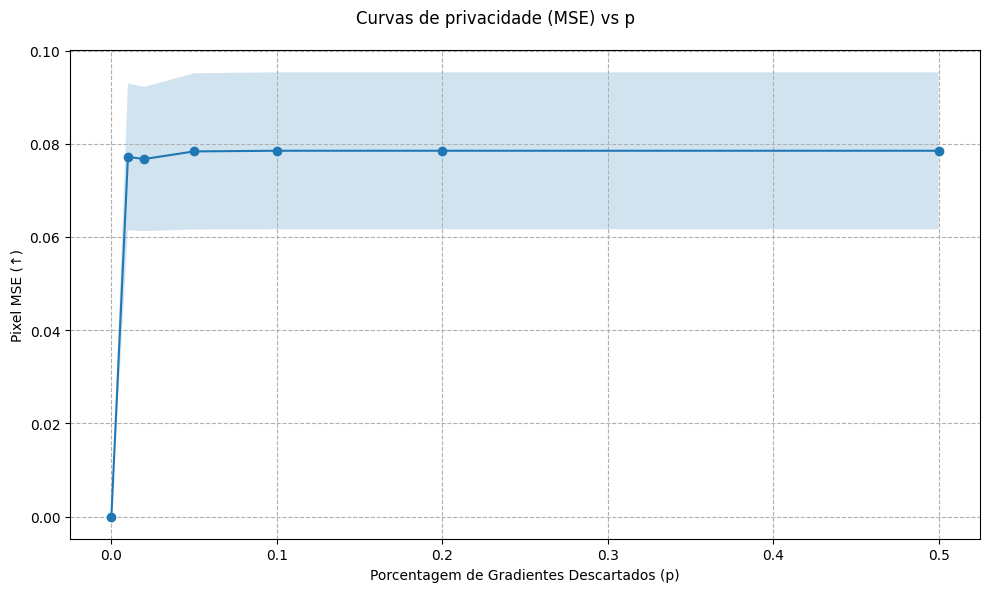


Acurácia média de inferência de rótulo por p:
   p_drop  lbl_acc
0    0.00      1.0
1    0.01      0.0
2    0.02      0.0
3    0.05      0.0
4    0.10      0.0
5    0.20      0.0
6    0.50      0.0


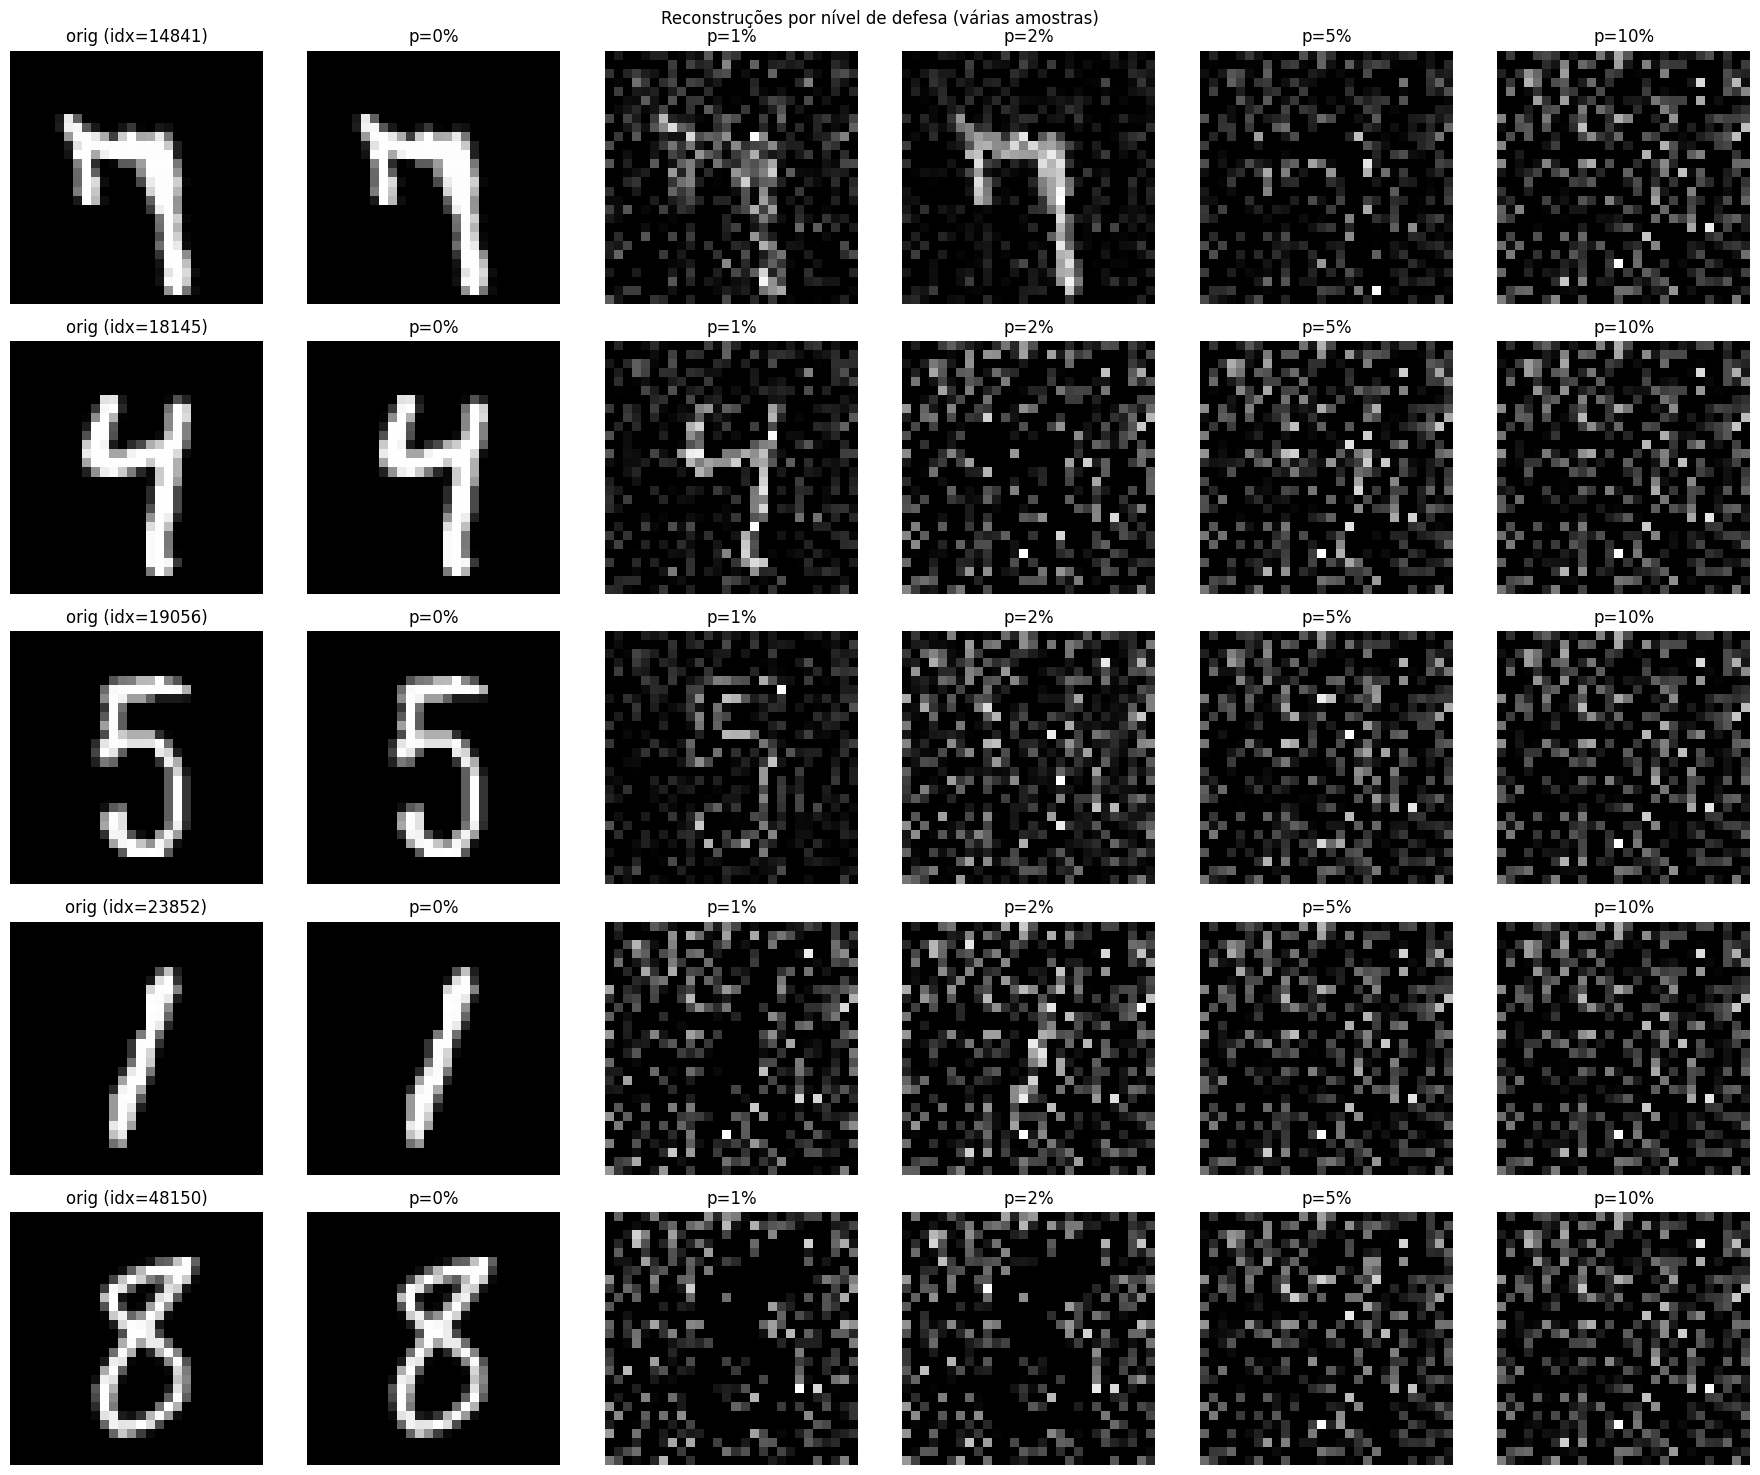

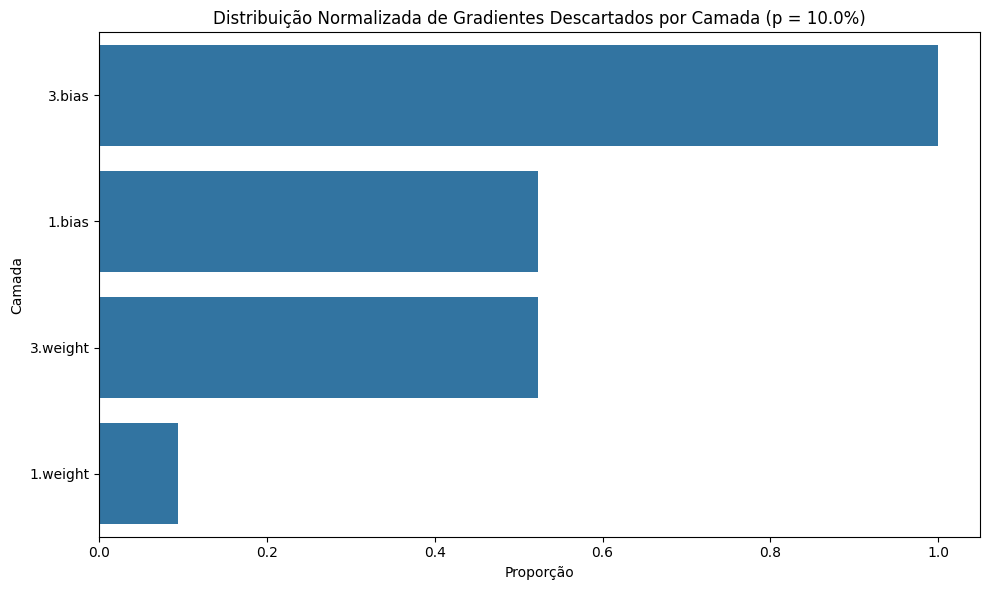


Treinando modelos com defesa para medir utilidade (acurácia)...


Treinando p/ utilidade (acurácia): 100%|██████████| 7/7 [01:20<00:00, 11.46s/it]



--- SUMÁRIO (Utilidade) ---
   p_drop  test_acc
0    0.00    0.9382
1    0.01    0.9048
2    0.02    0.8942
3    0.05    0.8834
4    0.10    0.8680
5    0.20    0.8096
6    0.50    0.1122


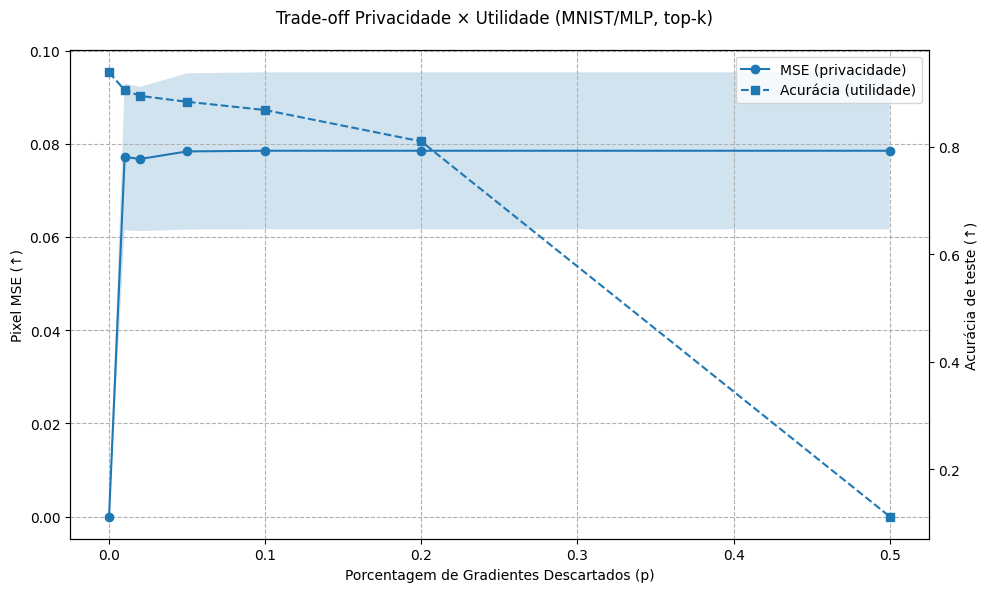

In [ ]:
# -*- coding: utf-8 -*-
import os, random, math
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import pandas as pd
import seaborn as sns

# ==========================
# Configs gerais
# ==========================
SAVE_CSV   = True
SAVE_FIGS  = False
OUTDIR     = "./resultados_mnist_topk"
os.makedirs(OUTDIR, exist_ok=True)

# Curva de privacidade (ataque)
P_VALUES   = [0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5]
N_RUNS     = 3

# >>> NOVO: quantas amostras do dataset usar no ataque
N_SAMPLES_PRIVACY = 5
STRATIFIED_SAMPLES = True  # tenta pegar rótulos distintos
SAMPLE_SEED = 123

# Curva de utilidade (treino com defesa)
RUN_UTILITY           = True
UTILITY_EPOCHS        = 3
UTILITY_LR            = 0.1
UTILITY_BATCH_SIZE    = 128
UTILITY_LIMIT_TRAIN   = 20000
UTILITY_LIMIT_TEST    = 5000

# =========
# Sementes
# =========
def set_seeds(seed: int = 42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# --------------------------
# 1) Dados e modelo
# --------------------------
def get_data_loader(name='MNIST', batch_size=64):
    if name == 'MNIST':
        transform = transforms.ToTensor()
        dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    else:
        raise NotImplementedError(f"Dataset {name} não implementado.")
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return loader, dataset

def get_train_test_loaders(batch_size=128, limit_train=None, limit_test=None):
    tfm = transforms.ToTensor()
    train_set = datasets.MNIST(root='./data', train=True, download=True, transform=tfm)
    test_set  = datasets.MNIST(root='./data', train=False, download=True, transform=tfm)
    if limit_train is not None:
        train_set = Subset(train_set, list(range(min(limit_train, len(train_set)))))
    if limit_test is not None:
        test_set  = Subset(test_set,  list(range(min(limit_test,  len(test_set)))))
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, drop_last=False)
    test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False, drop_last=False)
    return train_loader, test_loader

def create_model(dataset_name='MNIST'):
    if dataset_name == 'MNIST':
        return nn.Sequential(nn.Flatten(), nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, 10))
    else:
        raise NotImplementedError(f"Modelo para {dataset_name} não implementado.")

# --------------------------
# 2) Ataque iDLG + matching
# --------------------------
def compute_gradient(model, x, y):
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    for p in model.parameters():
        if p.grad is not None:
            p.grad = None
    loss = loss_fn(model(x), y)
    # sem grafo: é só o alvo para o ataque
    return torch.autograd.grad(loss, tuple(model.parameters()), create_graph=False)

@torch.no_grad()
def infer_label_from_last_bias_grad(model, original_gradient):
    last_bias_grad = None
    for (name, _), g in zip(model.named_parameters(), original_gradient):
        if name.endswith('bias'):
            last_bias_grad = g.detach().flatten()
    if last_bias_grad is None:
        raise RuntimeError("Não encontrei gradiente de bias da última camada.")
    return int(torch.argmin(last_bias_grad).item())

def reconstruct_image(model, original_gradient, lr=1.0, iters=600, device='cpu', seed=42):
    set_seeds(seed); model.eval()
    y_idx = infer_label_from_last_bias_grad(model, original_gradient)
    y_true = torch.tensor([y_idx], dtype=torch.long, device=device)
    x_hat = torch.rand(1, 1, 28, 28, requires_grad=True, device=device)
    optimizer = optim.LBFGS([x_hat], lr=lr, max_iter=20)
    rounds = max(1, iters // 20)
    def closure():
        optimizer.zero_grad(set_to_none=True)
        pred = model(x_hat)
        ce = nn.CrossEntropyLoss()(pred, y_true)
        syn = torch.autograd.grad(ce, tuple(model.parameters()), create_graph=True)
        diff = 0.0
        for sg, og in zip(syn, original_gradient):
            diff = diff + ((sg - og) ** 2).sum()
        diff.backward()
        return diff
    for _ in range(rounds):
        optimizer.step(closure)
        with torch.no_grad():
            x_hat.clamp_(0.0, 1.0)
    return x_hat.detach(), y_idx

# --------------------------
# 3) Defesa top-k global (alvo do ataque)
# --------------------------
def apply_gradient_dropping_defense(gradients, model, p_drop):
    if p_drop <= 0:
        layer_names = {name: 0 for name, _ in model.named_parameters()}
        return gradients, layer_names
    flat = torch.cat([g.reshape(-1) for g in gradients])
    N = flat.numel()
    k = int(round(N * p_drop))
    k = min(max(k, 0), N)
    if k == 0:
        layer_names = {name: 0 for name, _ in model.named_parameters()}
        return gradients, layer_names
    topk_idx = torch.topk(flat.abs(), k, largest=True).indices
    mask = torch.ones_like(flat, dtype=torch.bool); mask[topk_idx] = False
    flat_def = flat * mask.float()
    defended, counts = [], {name: 0 for name, _ in model.named_parameters()}
    names = list(counts.keys()); cur = 0
    for i, p in enumerate(model.parameters()):
        n = p.numel()
        grad_slice = flat_def[cur:cur+n]; mask_slice = mask[cur:cur+n]
        counts[names[i]] = int((~mask_slice).sum().item())
        defended.append(grad_slice.view_as(p).clone()); cur += n
    return tuple(defended), counts

# --------------------------
# 4) Métricas rápidas
# --------------------------
def mse_np(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.mean((a.astype(np.float32) - b.astype(np.float32))**2))

def psnr_from_mse(mse: float, data_range: float = 1.0) -> float:
    if mse <= 1e-12: return float('inf')
    return 10.0 * math.log10((data_range ** 2) / mse)

# --------------------------
# >>> NOVO: escolha de amostras
# --------------------------
def _get_targets(dataset):
    if hasattr(dataset, "targets"):
        return dataset.targets
    if hasattr(dataset, "dataset") and hasattr(dataset.dataset, "targets"):
        return dataset.dataset.targets
    raise RuntimeError("Não foi possível acessar os rótulos do dataset.")

def pick_sample_indices(dataset, n=5, seed=123, stratified=True):
    """Retorna n índices do dataset (preferindo rótulos distintos se stratified=True)."""
    rng = np.random.default_rng(seed)
    N = len(dataset); idxs = np.arange(N); rng.shuffle(idxs)
    targets = np.array(_get_targets(dataset)).astype(int)
    if not stratified:
        return list(idxs[:n])
    chosen, seen = [], set()
    for i in idxs:
        y = int(targets[i])
        if y not in seen:
            chosen.append(int(i)); seen.add(y)
            if len(chosen) == n: break
    # se ainda faltar (pouco provável), completa aleatoriamente
    if len(chosen) < n:
        for i in idxs:
            if i not in chosen:
                chosen.append(int(i))
                if len(chosen) == n: break
    return chosen

# --------------------------
# 5) Experimento de privacidade (múltiplas amostras)
# --------------------------
def run_defense_experiment_multi(model, dataset, device, sample_indices, p_values=P_VALUES, n_runs=N_RUNS):
    results = []
    originals = {}  # sample_idx -> tensor original
    for sample_idx in sample_indices:
        original_x, original_y_idx = dataset[sample_idx]
        original_x = original_x.unsqueeze(0).to(device)
        original_y = torch.tensor([original_y_idx], device=device)
        originals[sample_idx] = original_x.cpu()
        # grad-alvo para ESTA amostra
        original_gradient = compute_gradient(model, original_x, original_y)
        for p in tqdm(p_values, desc=f"amostra {sample_idx} (y={int(original_y_idx)})", leave=False):
            for run in range(n_runs):
                seed = 42 * (run + 1)
                defended_g, layer_drops = apply_gradient_dropping_defense(original_gradient, model, p)
                detached = tuple(g.detach() for g in defended_g)
                recon_x, y_est = reconstruct_image(model, detached, device=device, seed=seed)
                a = original_x.detach().cpu().numpy().reshape(-1)
                b = recon_x.detach().cpu().numpy().reshape(-1)
                privacy_mse  = mse_np(a, b)
                privacy_psnr = psnr_from_mse(privacy_mse, data_range=1.0)
                results.append({
                    'sample_idx': int(sample_idx),
                    'digit': int(original_y_idx),
                    'p_drop': p,
                    'run': run,
                    'privacy_mse': privacy_mse,
                    'privacy_psnr': privacy_psnr,
                    'layer_drops': layer_drops,
                    'recon_image': recon_x.cpu(),
                    'y_true': int(original_y.item()),
                    'y_pred': int(y_est),
                    'label_ok': int(y_est == int(original_y.item()))
                })
    df = pd.DataFrame(results)
    if SAVE_CSV:
        df.to_csv(os.path.join(OUTDIR, f"mnist_topk_privacidade_multi.csv"), index=False)
    return df, originals

# --------------------------
# 6) Utilidade (treino com defesa)
# --------------------------
@torch.no_grad()
def evaluate_accuracy(model, loader, device):
    model.eval(); correct=0; total=0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(dim=1)
        correct += (pred==y).sum().item(); total += y.numel()
    return correct/max(1,total)

def apply_mask_inplace(model, p_drop: float):
    if p_drop <= 0: return
    grads = [ (p.grad if p.grad is not None else torch.zeros_like(p)) for p in model.parameters() ]
    flat  = torch.cat([g.reshape(-1) for g in grads])
    N = flat.numel(); k = int(round(N*p_drop))
    if k <= 0: return
    if k >= N:
        for p in model.parameters():
            if p.grad is not None: p.grad.zero_()
        return
    topk_idx = torch.topk(flat.abs(), k, largest=True).indices
    mask = torch.ones_like(flat, dtype=torch.bool); mask[topk_idx] = False
    flat_def = flat * mask.float()
    cur=0
    for p in model.parameters():
        n = p.numel()
        if p.grad is not None:
            p.grad.copy_(flat_def[cur:cur+n].view_as(p))
        cur += n

def train_with_defense_once(p_drop: float, device, epochs=UTILITY_EPOCHS, lr=UTILITY_LR):
    set_seeds(123)
    model = create_model('MNIST').to(device)
    train_loader, test_loader = get_train_test_loaders(
        batch_size=UTILITY_BATCH_SIZE, limit_train=UTILITY_LIMIT_TRAIN, limit_test=UTILITY_LIMIT_TEST
    )
    opt = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(set_to_none=True)
            loss = loss_fn(model(x), y); loss.backward()
            apply_mask_inplace(model, p_drop); opt.step()
    return evaluate_accuracy(model, test_loader, device)

def run_utility_curve(device, p_values=P_VALUES):
    rows=[]
    for p in tqdm(p_values, desc="Treinando p/ utilidade (acurácia)"):
        rows.append({"p_drop": p, "test_acc": train_with_defense_once(p, device)})
    df = pd.DataFrame(rows)
    if SAVE_CSV:
        df.to_csv(os.path.join(OUTDIR, "mnist_topk_utilidade.csv"), index=False)
    return df

# --------------------------
# 7) Plots
# --------------------------
def plot_tradeoff_curve(df_results):
    fig, ax = plt.subplots(figsize=(10,6))
    summary = df_results.groupby('p_drop').agg(
        avg_mse=('privacy_mse','mean'),
        std_mse=('privacy_mse','std'),
        avg_psnr=('privacy_psnr','mean'),
        lbl_acc=('label_ok','mean')
    ).reset_index()
    ax.plot(summary['p_drop'], summary['avg_mse'], marker='o', label='MSE (privacidade)')
    ax.fill_between(summary['p_drop'],
                    summary['avg_mse']-summary['std_mse'],
                    summary['avg_mse']+summary['std_mse'], alpha=0.2)
    ax.set_xlabel('Porcentagem de Gradientes Descartados (p)')
    ax.set_ylabel('Pixel MSE (↑)')
    plt.grid(True, linestyle='--'); plt.suptitle('Curvas de privacidade (MSE) vs p')
    plt.tight_layout();
    if SAVE_FIGS: plt.savefig(os.path.join(OUTDIR,"tradeoff_mse.png"), dpi=200)
    plt.show()
    print("\nAcurácia média de inferência de rótulo por p:")
    print(summary[['p_drop','lbl_acc']])

def plot_tradeoff_mse_acc(df_privacy, df_utility):
    s_priv = df_privacy.groupby('p_drop').agg(
        avg_mse=('privacy_mse','mean'),
        std_mse=('privacy_mse','std')
    ).reset_index()
    s_util = df_utility.sort_values('p_drop').reset_index(drop=True)

    fig, ax1 = plt.subplots(figsize=(10,6))
    ax1.plot(s_priv['p_drop'], s_priv['avg_mse'], marker='o', label='MSE (privacidade)')
    ax1.fill_between(s_priv['p_drop'], s_priv['avg_mse']-s_priv['std_mse'],
                     s_priv['avg_mse']+s_priv['std_mse'], alpha=0.2)
    ax1.set_xlabel('Porcentagem de Gradientes Descartados (p)')
    ax1.set_ylabel('Pixel MSE (↑)'); ax1.grid(True, linestyle='--')

    ax2 = ax1.twinx()
    ax2.plot(s_util['p_drop'], s_util['test_acc'], marker='s', linestyle='--', label='Acurácia (utilidade)')
    ax2.set_ylabel('Acurácia de teste (↑)')

    l1,lb1 = ax1.get_legend_handles_labels()
    l2,lb2 = ax2.get_legend_handles_labels()
    ax2.legend(l1+l2, lb1+lb2, loc='best')

    plt.suptitle('Trade-off Privacidade × Utilidade (MNIST/MLP, top-k)')
    plt.tight_layout()
    if SAVE_FIGS: plt.savefig(os.path.join(OUTDIR,"tradeoff_mse_acc.png"), dpi=200)
    plt.show()

def plot_layerwise_analysis(df_results, p_value, model):
    subset = df_results[df_results['p_drop']==p_value]
    if subset.empty: return
    # pega a primeira linha (você pode agregar se quiser)
    layer_drops = subset['layer_drops'].iloc[0]
    sizes = {name: p.numel() for name,p in model.named_parameters()}
    prop = {name: (layer_drops.get(name,0)/max(1,sizes.get(name,1))) for name in layer_drops}
    df_layers = (pd.DataFrame(list(prop.items()), columns=['Camada','Proporção'])
                   .sort_values('Proporção', ascending=False))
    plt.figure(figsize=(10,6))
    sns.barplot(data=df_layers.head(15), x='Proporção', y='Camada')
    plt.title(f'Distribuição Normalizada de Gradientes Descartados por Camada (p = {p_value*100:.1f}%)')
    plt.xlabel('Proporção'); plt.ylabel('Camada'); plt.tight_layout()
    if SAVE_FIGS: plt.savefig(os.path.join(OUTDIR,f"layerwise_p{int(p_value*100)}.png"), dpi=200)
    plt.show()

# >>> NOVO: grade qualitativa para várias amostras
def plot_qualitative_multi(originals_map, df_results, p_values_to_show=None):
    if p_values_to_show is None:
        p_values_to_show = sorted(df_results['p_drop'].unique())
    sample_indices = sorted(list(originals_map.keys()))
    cols = 1 + len(p_values_to_show)
    rows = len(sample_indices)
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
    if rows == 1: axes = np.expand_dims(axes, 0)
    for r, sidx in enumerate(sample_indices):
        # original
        ax = axes[r,0]
        ax.imshow(originals_map[sidx].squeeze(), cmap='gray'); ax.set_title(f"orig (idx={sidx})"); ax.axis('off')
        for c, p in enumerate(p_values_to_show, start=1):
            df1 = df_results[(df_results['sample_idx']==sidx) & (df_results['p_drop']==p) & (df_results['run']==0)]
            if df1.empty:
                axes[r,c].axis('off'); continue
            recon = df1['recon_image'].iloc[0]
            axes[r,c].imshow(recon.squeeze(), cmap='gray'); axes[r,c].set_title(f"p={p*100:.0f}%"); axes[r,c].axis('off')
    plt.suptitle("Reconstruções por nível de defesa (várias amostras)")
    plt.tight_layout();
    if SAVE_FIGS: plt.savefig(os.path.join(OUTDIR,"qualitativo_multi.png"), dpi=200)
    plt.show()

# --------------------------
# 8) Main
# --------------------------
def main():
    set_seeds(42)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Usando dispositivo: {device}")

    _, dataset = get_data_loader('MNIST')
    global model
    model = create_model('MNIST').to(device)

    # >>> escolhe 5 amostras do dataset
    sample_indices = pick_sample_indices(dataset, n=N_SAMPLES_PRIVACY,
                                         seed=SAMPLE_SEED, stratified=STRATIFIED_SAMPLES)
    print("Amostras selecionadas:", sample_indices)

    print("Rodando ataque (privacidade) nessas amostras...")
    df_priv, originals_map = run_defense_experiment_multi(model, dataset, device, sample_indices)

    print("\n--- SUMÁRIO (Privacidade, média sobre amostras × runs) ---")
    print(df_priv.groupby('p_drop').agg(avg_mse=('privacy_mse','mean'),
                                        std_mse=('privacy_mse','std'),
                                        lbl_acc=('label_ok','mean')).reset_index())

    plot_tradeoff_curve(df_priv)
    plot_qualitative_multi(originals_map, df_priv, p_values_to_show=[0.0,0.01,0.02,0.05,0.1])
    plot_layerwise_analysis(df_priv, p_value=0.1, model=model)

    if RUN_UTILITY:
        print("\nTreinando modelos com defesa para medir utilidade (acurácia)...")
        df_util = run_utility_curve(device, P_VALUES)
        print("\n--- SUMÁRIO (Utilidade) ---")
        print(df_util)
        plot_tradeoff_mse_acc(df_priv, df_util)

if __name__ == "__main__":
    main()


In [ ]:

# ---------- Config ----------
GRID_ARCHS = ["mlp", "cnn", "vit"]
GRID_DATASETS = ["mnist", "fashion-mnist", "cifar10"]
GRID_DEFENSES = ["none", "topk", "dpsgd", "randomk", "qsgd"]
GRID_BATCHES = [1, 32]

GRID_EPOCHS = 1            # aumente para 3+ para resultados mais estáveis
GRID_LR = 1e-3
GRID_LIMIT_TRAIN = 4000    # para acelerar
GRID_LIMIT_TEST = 1000
GRID_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TOPK_KEEP_RATIO = 0.1      # mantém top 10% (maior magnitude)
RANDOMK_KEEP_RATIO = 0.1   # mantém 10% aleatório
DP_NOISE_MULT = 1.0        # sigma
DP_CLIP_NORM = 1.0         # clipping L2 global dos gradientes
QSGD_LEVELS = 16           # níveis de quantização


# ---------- Dados ----------
def _dataset_transforms(name: str):
    name = name.lower()
    if name in ["mnist", "fashion-mnist"]:
        mean_std = ((0.1307,), (0.3081,)) if name == "mnist" else ((0.2860,), (0.3530,))
        tfm = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(*mean_std),
        ])
        return tfm, 1, 28, 10
    elif name == "cifar10":
        tfm = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
        ])
        return tfm, 3, 32, 10
    else:
        raise ValueError(f"Dataset não suportado: {name}")


def get_train_test_loaders_generic(dataset_name: str, batch_size: int, limit_train=None, limit_test=None):
    tfm, in_ch, img_size, num_classes = _dataset_transforms(dataset_name)
    name = dataset_name.lower()

    if name == "mnist":
        train_set = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
        test_set = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)
    elif name == "fashion-mnist":
        train_set = datasets.FashionMNIST(root="./data", train=True, download=True, transform=tfm)
        test_set = datasets.FashionMNIST(root="./data", train=False, download=True, transform=tfm)
    elif name == "cifar10":
        train_set = datasets.CIFAR10(root="./data", train=True, download=True, transform=tfm)
        test_set = datasets.CIFAR10(root="./data", train=False, download=True, transform=tfm)
    else:
        raise ValueError(f"Dataset não suportado: {dataset_name}")

    if limit_train is not None:
        train_set = Subset(train_set, list(range(min(limit_train, len(train_set)))))
    if limit_test is not None:
        test_set = Subset(test_set, list(range(min(limit_test, len(test_set)))))

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, drop_last=False)
    test_loader = DataLoader(test_set, batch_size=max(64, batch_size), shuffle=False, drop_last=False)
    return train_loader, test_loader, in_ch, img_size, num_classes


# ---------- Modelos ----------
class MLPNet(nn.Module):
    def __init__(self, in_ch, img_size, num_classes):
        super().__init__()
        d = in_ch * img_size * img_size
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(d, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.net(x)


class CNNNet(nn.Module):
    def __init__(self, in_ch, img_size, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        reduced = img_size // 4
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * reduced * reduced, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


class TinyViT(nn.Module):
    def __init__(self, in_ch, img_size, num_classes, patch_size=4, emb_dim=128, depth=4, n_heads=4, mlp_ratio=2.0):
        super().__init__()
        assert img_size % patch_size == 0, "img_size deve ser divisível por patch_size"
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2

        self.patch_proj = nn.Conv2d(in_ch, emb_dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, emb_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + self.n_patches, emb_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            nhead=n_heads,
            dim_feedforward=int(emb_dim * mlp_ratio),
            dropout=0.1,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.head = nn.Linear(emb_dim, num_classes)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        b = x.size(0)
        x = self.patch_proj(x)               # [B, D, H', W']
        x = x.flatten(2).transpose(1, 2)     # [B, N, D]
        cls = self.cls_token.expand(b, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_embed[:, :x.size(1)]
        x = self.encoder(x)
        return self.head(x[:, 0])


def build_model(arch: str, in_ch: int, img_size: int, num_classes: int) -> nn.Module:
    arch = arch.lower()
    if arch == "mlp":
        return MLPNet(in_ch, img_size, num_classes)
    if arch == "cnn":
        return CNNNet(in_ch, img_size, num_classes)
    if arch == "vit":
        return TinyViT(in_ch, img_size, num_classes)
    raise ValueError(f"Arquitetura não suportada: {arch}")


# ---------- Defesas nos gradientes ----------
def _flatten_grads(grads):
    flat = []
    shapes = []
    for g in grads:
        if g is None:
            shapes.append(None)
            continue
        shapes.append(g.shape)
        flat.append(g.reshape(-1))
    if len(flat) == 0:
        return None, shapes
    return torch.cat(flat), shapes


def _unflatten_to_params(vec, params, shapes):
    out = []
    ptr = 0
    for p, shp in zip(params, shapes):
        if shp is None:
            out.append(None)
            continue
        n = p.numel()
        out.append(vec[ptr:ptr + n].view_as(p))
        ptr += n
    return out


def defense_none(grads):
    return grads


def defense_topk(grads, keep_ratio=TOPK_KEEP_RATIO):
    flat, shapes = _flatten_grads(grads)
    if flat is None:
        return grads
    n = flat.numel()
    k = max(1, int(n * keep_ratio))
    idx = torch.topk(flat.abs(), k=k, largest=True).indices
    mask = torch.zeros_like(flat)
    mask[idx] = 1.0
    kept = flat * mask
    return _unflatten_to_params(kept, grads, shapes)


def defense_randomk(grads, keep_ratio=RANDOMK_KEEP_RATIO):
    flat, shapes = _flatten_grads(grads)
    if flat is None:
        return grads
    n = flat.numel()
    k = max(1, int(n * keep_ratio))
    perm = torch.randperm(n, device=flat.device)
    idx = perm[:k]
    mask = torch.zeros_like(flat)
    mask[idx] = 1.0
    kept = flat * mask
    return _unflatten_to_params(kept, grads, shapes)


def defense_dpsgd(grads, clip_norm=DP_CLIP_NORM, noise_mult=DP_NOISE_MULT):
    flat, shapes = _flatten_grads(grads)
    if flat is None:
        return grads

    norm = torch.norm(flat, p=2)
    scale = min(1.0, clip_norm / (norm + 1e-12))
    flat = flat * scale
    noise = torch.randn_like(flat) * (noise_mult * clip_norm)
    flat = flat + noise
    return _unflatten_to_params(flat, grads, shapes)


def defense_qsgd(grads, levels=QSGD_LEVELS):
    flat, shapes = _flatten_grads(grads)
    if flat is None:
        return grads

    s = torch.norm(flat, p=2)
    if s < 1e-12:
        return grads

    abs_x = flat.abs()
    scaled = levels * abs_x / (s + 1e-12)
    floor_v = torch.floor(scaled)
    prob = scaled - floor_v
    rnd = torch.rand_like(prob)
    q = floor_v + (rnd < prob).float()
    q = torch.clamp(q, max=levels)

    quantized = torch.sign(flat) * s * q / levels
    return _unflatten_to_params(quantized, grads, shapes)


def apply_defense(grads, defense_name: str):
    d = defense_name.lower()
    if d == "none":
        return defense_none(grads)
    if d == "topk":
        return defense_topk(grads)
    if d == "randomk":
        return defense_randomk(grads)
    if d == "dpsgd":
        return defense_dpsgd(grads)
    if d == "qsgd":
        return defense_qsgd(grads)
    raise ValueError(f"Defesa não suportada: {defense_name}")


# ---------- Treino/Avaliação ----------
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total = 0
    correct = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return correct / max(1, total)


def train_one_epoch_with_defense(model, loader, optimizer, device, defense_name: str):
    model.train()
    loss_fn = nn.CrossEntropyLoss()
    running_loss = 0.0
    n = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()

        # coleta, aplica defesa e escreve gradientes de volta
        params = [p for p in model.parameters()]
        grads = [p.grad if p.grad is not None else None for p in params]
        defended = apply_defense(grads, defense_name)

        for p, g in zip(params, defended):
            if g is None:
                p.grad = None
            else:
                p.grad = g

        optimizer.step()

        bs = y.size(0)
        running_loss += loss.item() * bs
        n += bs

    return running_loss / max(1, n)


@dataclass
class ExperimentConfig:
    arch: str
    dataset: str
    defense: str
    batch_size: int
    epochs: int = GRID_EPOCHS
    lr: float = GRID_LR


def run_single_experiment(cfg: ExperimentConfig, device=GRID_DEVICE):
    train_loader, test_loader, in_ch, img_size, num_classes = get_train_test_loaders_generic(
        cfg.dataset,
        cfg.batch_size,
        limit_train=GRID_LIMIT_TRAIN,
        limit_test=GRID_LIMIT_TEST,
    )

    model = build_model(cfg.arch, in_ch, img_size, num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    train_losses = []
    for _ in range(cfg.epochs):
        train_loss = train_one_epoch_with_defense(model, train_loader, optimizer, device, cfg.defense)
        train_losses.append(train_loss)

    test_acc = evaluate(model, test_loader, device)

    return {
        "arch": cfg.arch,
        "dataset": cfg.dataset,
        "defense": cfg.defense,
        "batch_size": cfg.batch_size,
        "epochs": cfg.epochs,
        "lr": cfg.lr,
        "train_loss_last": train_losses[-1] if train_losses else None,
        "test_acc": test_acc,
    }


def run_full_grid_experiment(
    archs=GRID_ARCHS,
    datasets_list=GRID_DATASETS,
    defenses=GRID_DEFENSES,
    batches=GRID_BATCHES,
    epochs=GRID_EPOCHS,
    lr=GRID_LR,
    device=GRID_DEVICE,
):
    rows = []
    configs = [
        ExperimentConfig(a, d, f, b, epochs=epochs, lr=lr)
        for a, d, f, b in product(archs, datasets_list, defenses, batches)
    ]

    print(f"Executando {len(configs)} experimentos em {device}...")
    for i, cfg in enumerate(configs, start=1):
        print(f"[{i:03d}/{len(configs)}] arch={cfg.arch:>3} | data={cfg.dataset:>13} | def={cfg.defense:>7} | bsz={cfg.batch_size}")
        try:
            result = run_single_experiment(cfg, device=device)
            rows.append(result)
        except Exception as e:
            rows.append({
                "arch": cfg.arch,
                "dataset": cfg.dataset,
                "defense": cfg.defense,
                "batch_size": cfg.batch_size,
                "epochs": cfg.epochs,
                "lr": cfg.lr,
                "train_loss_last": None,
                "test_acc": None,
                "error": str(e),
            })
            print(f"  -> erro: {e}")

    df = pd.DataFrame(rows)
    return df


# ---------- Execução ----------
set_seeds(42)

df_grid = run_full_grid_experiment(
    archs=GRID_ARCHS,
    datasets_list=GRID_DATASETS,
    defenses=GRID_DEFENSES,
    batches=GRID_BATCHES,
    epochs=GRID_EPOCHS,
    lr=GRID_LR,
    device=GRID_DEVICE,
)

print("\nResultados brutos (primeiras linhas):")
print(df_grid.head())

print("\nResumo por combinação (média de acurácia quando aplicável):")
summary = (
    df_grid.groupby(["arch", "dataset", "defense", "batch_size"], dropna=False)["test_acc"]
    .mean()
    .reset_index()
    .sort_values(["dataset", "arch", "defense", "batch_size"])
)
print(summary)

csv_path = "./resultados_grid_privacidade_utilidade.csv"
df_grid.to_csv(csv_path, index=False)
print(f"\nCSV salvo em: {csv_path}")